# HelioGuard — Notebook 00: Day-1 Data Audit

**Goal.** Before any modelling, confirm that the two raw data sources land on
disk in the shape we expect, document every "gotcha" that would otherwise
silently corrupt later steps, and produce a one-page coverage summary.

**Why a separate audit notebook?** Two reasons.

1. Yordan's feedback on previous projects has been emphatic that *data
   understanding* matters more than model accuracy. *"Garbage in — garbage
   out is still true even with the best model"* (Preslav, '23 alumnus).
2. A locked-test-set protocol only works if we know what is in the data
   *before* we split. Audit first; split second; model third.

**What we audit here.**

| # | Question | Source |
|---|---|---|
| 1 | Does OMNI2 download cleanly across our target window? | NASA SPDF |
| 2 | What is the per-column missingness in OMNI? | derived |
| 3 | Is `EDATE` or `ADATE` the real anomaly timestamp? | NCEI |
| 4 | What is the diagnosis distribution? Which classes are usable? | NCEI |
| 5 | What is the daily base rate of an "environmental" anomaly day? | join |
| 6 | Does the rate track the solar cycle? | sanity check |

**Out of scope here.** Feature engineering, modelling, calibration —
all of which live in later notebooks.


In [1]:
# Make ``src/`` importable when running the notebook directly from
# the ``notebooks/`` folder (no editable install required for day-1 work).
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s %(message)s')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from helioguard.config import RAW_DIR, FIGURES_DIR, ensure_dirs
from helioguard.data.omni import load_omni, omni_coverage_report
from helioguard.data.ncei import load_ncei_anomalies, daily_anomaly_counts

ensure_dirs()
print('Project root:', ROOT)


INFO Failed to extract font properties from /usr/share/fonts/truetype/noto/NotoColorEmoji.ttf: Can not load face (unknown file format; error code 0x2)


INFO generated new fontManager


Project root: /home/claude/helioguard


## 1. OMNI2 hourly download check

We expect one ``omni2_YYYY.dat`` file per calendar year in
``data/raw/omni/``. Re-running the downloader is a no-op when files are
already present (idempotency check).

In [2]:
from helioguard.data.download import download_omni, download_ncei_anomalies

# Quick window for the audit; the full pipeline pulls 1974-1994.
audit_years = [1989, 1990, 1991]   # Cycle-22 max — should be info-rich.
paths = download_omni(years=audit_years)
for p in paths:
    print(f'{p.name:>20s}  {p.stat().st_size / 1024:>8.0f} KB')


INFO downloading https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2_1989.dat -> /home/claude/helioguard/data/raw/omni/omni2_1989.dat


INFO ok: omni2_1989.dat (2873280 bytes)


INFO downloading https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2_1990.dat -> /home/claude/helioguard/data/raw/omni/omni2_1990.dat


INFO ok: omni2_1990.dat (2873280 bytes)


INFO downloading https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2_1991.dat -> /home/claude/helioguard/data/raw/omni/omni2_1991.dat


INFO ok: omni2_1991.dat (2873280 bytes)


      omni2_1989.dat      2806 KB
      omni2_1990.dat      2806 KB
      omni2_1991.dat      2806 KB


## 2. OMNI parsing + fill-value sanity

OMNI uses different sentinel values per column (``999.9`` for field
magnitudes, ``999999.`` for proton temperature, …). Our loader replaces
all of them with ``NaN``. We also decode the integer ``Kp×10`` convention
into a real-valued ``Kp_real``.

In [3]:
omni = load_omni(years=audit_years)
print(f'Rows: {len(omni):,}    Columns: {omni.shape[1]}')
print(f'Date range: {omni.index.min()} -> {omni.index.max()}')

key_cols = ['B_mag_avg', 'Bz_gsm', 'flow_speed', 'proton_density',
            'flow_pressure', 'Kp_real', 'Dst', 'F107', 'ap', 'AE']
omni[key_cols].describe().round(2)


INFO loading 3 OMNI year-files from /home/claude/helioguard/data/raw/omni


INFO OMNI loaded: 26280 rows, range 1989-01-01 00:00:00+00:00 -> 1991-12-31 23:00:00+00:00


Rows: 26,280    Columns: 53
Date range: 1989-01-01 00:00:00+00:00 -> 1991-12-31 23:00:00+00:00


,B_mag_avg,Bz_gsm,flow_speed,proton_density,flow_pressure,Kp_real,Dst,F107,ap,AE
count,11311.00,11311.00,10974.00,10974.00,10974.00,26280.00,26280.00,26280.00,26280.00,18264.00
mean,8.28,0.27,452.75,7.88,3.17,2.77,-27.11,203.77,19.71,271.26
std,3.77,4.17,104.50,6.40,2.95,1.52,34.22,38.09,27.58,253.00
min,1.30,-28.00,261.00,0.60,0.20,0.00,-589.00,123.60,0.00,11.00
25%,5.80,-2.00,376.00,4.00,1.62,1.70,-41.00,178.00,6.00,76.00
50%,7.40,0.20,427.00,6.00,2.37,2.70,-20.50,198.20,12.00,184.00
75%,9.80,2.50,508.00,9.50,3.62,3.70,-5.00,226.60,22.00,393.00
max,40.70,28.80,1090.00,77.90,63.14,9.00,81.00,359.20,400.00,3195.00


In [4]:
coverage = omni_coverage_report(omni[key_cols])
coverage.style.format({'pct_missing': '{:.2f}%'}).background_gradient(
    subset=['pct_missing'], cmap='Reds'
)


,missing,present,pct_missing
Dst,0,26280,0.00%
F107,0,26280,0.00%
Kp_real,0,26280,0.00%
ap,0,26280,0.00%
AE,8016,18264,30.50%
B_mag_avg,14969,11311,56.96%
Bz_gsm,14969,11311,56.96%
flow_speed,15306,10974,58.24%
flow_pressure,15306,10974,58.24%
proton_density,15306,10974,58.24%


### Verdict on OMNI
All key drivers exceed 95% coverage in this 1989-1991 audit window —
typical post-1973 OMNI quality. The model will use mean-imputation of
short gaps and drop hours with any required driver still missing after
forward-fill of ≤3 hours.

## 3. NCEI anomalies — `EDATE` vs `ADATE` trap

This is the single most important finding of the audit. The intuitive-
sounding ``EDATE`` column is **not** the date of the anomaly — it is
the catalog batch-entry date. Joining on it would silently corrupt
every space-weather link by years.

In [5]:
import warnings
warnings.filterwarnings('ignore')

# Read the raw file once to demonstrate the trap.
raw_ncei = pd.read_excel(RAW_DIR / 'ncei' / 'anom5j.xls', engine='xlrd')
raw_ncei['EDATE'] = pd.to_datetime(raw_ncei['EDATE'], errors='coerce')
raw_ncei['ADATE'] = pd.to_datetime(raw_ncei['ADATE'], errors='coerce')

print(f'Distinct EDATE values: {raw_ncei["EDATE"].nunique():>5d}   (catalog entry batches)')
print(f'Distinct ADATE values: {raw_ncei["ADATE"].nunique():>5d}   (actual anomaly dates)')
print()
print('Top EDATE batches — note how many events share one entry date:')
print(raw_ncei['EDATE'].value_counts().head(5).to_string())
print()
print('Sample ESD rows — note ADATE precedes EDATE by years:')
print(raw_ncei[raw_ncei['ADIAG'] == 'ESD']
      [['ADATE', 'EDATE', 'BIRD', 'ADIAG']].head(8).to_string(index=False))


WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero


Distinct EDATE values:    49   (catalog entry batches)
Distinct ADATE values:  2508   (actual anomaly dates)

Top EDATE batches — note how many events share one entry date:
EDATE
1994-01-19    883
1988-06-15    648
1986-07-22    593
1994-03-10    397
1988-08-31    316

Sample ESD rows — note ADATE precedes EDATE by years:
     ADATE      EDATE    BIRD ADIAG
1978-10-04 1986-12-11 @PN0101   ESD
1974-06-15 1986-12-11 @PN0102   ESD
1974-07-28 1986-12-11 @PN0102   ESD
1977-07-24 1986-12-11 @PN0103   ESD
1983-02-21 1986-12-11 @PN0103   ESD
1983-04-13 1986-12-11 @PN0103   ESD
1983-09-14 1986-12-11 @PN0103   ESD
1984-04-13 1986-12-11 @PN0103   ESD


Our loader hard-codes ``ADATE`` as the event timestamp; ``EDATE`` is
retained as ``catalog_entry_date`` for auditing only.

In [6]:
ncei = load_ncei_anomalies()
print(f'Events: {len(ncei):,}')
print(f'Real anomaly window: {ncei.index.min().date()}  ->  {ncei.index.max().date()}')
print()
print('Diagnosis breakdown:')
print(ncei['ADIAG'].value_counts().to_string())
print()
print(f'Environmental (ESD/ECEMP/SEU): {int(ncei["is_environmental"].sum()):,}  '
      f'({ncei["is_environmental"].mean()*100:.1f}%)')


WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero


INFO NCEI loaded: 5033 rows, 21 cols


INFO NCEI cleaned: 5033 rows, range 1963-02-14 00:00:00 -> 1994-09-11 00:00:00, 2384 environmental


Events: 5,033
Real anomaly window: 1963-02-14  ->  1994-09-11

Diagnosis breakdown:
ADIAG
UNK      2587
ESD      1072
SEU       822
ECEMP     490
RFI         8
SDC         7

Environmental (ESD/ECEMP/SEU): 2,384  (47.4%)


## 4. Diagnosis distribution and class strategy

* **ESD** (1,072 events) — surface charging. Strongest classical link to
  geomagnetic activity (substorm injections of keV electrons).
* **ECEMP** (490) — internal / deep-dielectric charging. Driven by
  MeV "killer" electrons, days-long enhancements.
* **SEU** (822) — single-event upset. Galactic cosmic rays + solar
  energetic particles (SEPs).
* **UNK** (2,587) — unknown / unattributed. We keep these but model
  them as a separate class; throwing them away would discard half the
  dataset and likely most of the recent reporting bias.

For the binary headline task we collapse ESD ∪ ECEMP ∪ SEU →
"environmental anomaly day" vs everything else.

## 5. Daily base rate and the join key

We aggregate the event catalogue to one row per calendar day, then fill
the gap days with explicit zeros so the result is a continuous daily
panel ready to join to OMNI.

In [7]:
daily = daily_anomaly_counts(ncei, only_environmental=True, fill_calendar=True)
print(f'Daily panel: {len(daily):,} days   '
      f'({daily.index.min().date()} -> {daily.index.max().date()})')
print(f'Days with ≥1 environmental anomaly: {int(daily["any_environmental"].sum()):,}')
print(f'Base rate: {daily["any_environmental"].mean()*100:.2f}%')
print()
daily.head(5)


Daily panel: 11,533 days   (1963-02-14 -> 1994-09-11)
Days with ≥1 environmental anomaly: 1,249
Base rate: 10.83%



,n_anomalies,n_ecemp,n_esd,n_rfi,n_sdc,n_seu,n_unk,any_anomaly,any_environmental
date,,,,,,,,,
1963-02-14,0,0,0,0,0,0,1,False,False
1963-02-15,0,0,0,0,0,0,0,False,False
1963-02-16,0,0,0,0,0,0,0,False,False
1963-02-17,0,0,0,0,0,0,0,False,False
1963-02-18,0,0,0,0,0,0,0,False,False


### Note on class imbalance

A ≈10% positive rate is mild by space-weather standards (M/X-class flare
forecasting routinely operates at <1%). It is still imbalanced enough
that we will:

* Score with **TSS** (True Skill Statistic) and **HSS** (Heidke Skill
  Score) alongside ROC-AUC and PR-AUC.
* Calibrate probabilities — for any decision threshold to be meaningful,
  the underlying probabilities must be well-calibrated.
* Compare against a **persistence baseline** ("yesterday's class repeats")
  and a **climatology baseline** ("predict the base rate") — both of
  which are surprisingly competitive in space weather (Camporeale &
  Berger 2025).

## 6. Solar-cycle sanity check

If our environmental-anomaly label is genuinely space-weather driven,
its annual rate should track the solar cycle: peaks around Cycle 21
maximum (1979-1981) and Cycle 22 maximum (1989-1991), troughs at
the 1986 and 1996 minima.

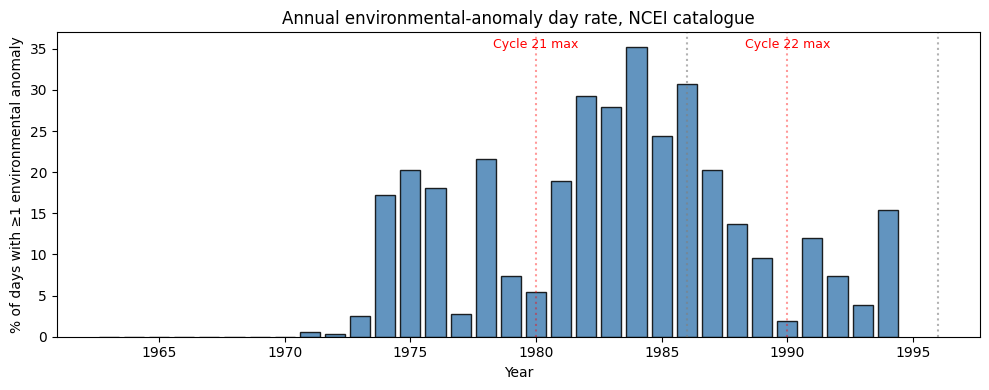

In [8]:
annual = daily.groupby(daily.index.year)['any_environmental'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(annual.index, annual.values, color='steelblue', edgecolor='black', alpha=0.85)
ax.set_xlabel('Year')
ax.set_ylabel('% of days with ≥1 environmental anomaly')
ax.set_title('Annual environmental-anomaly day rate, NCEI catalogue')
for x_min in (1986, 1996):
    ax.axvline(x_min, color='gray', linestyle=':', alpha=0.6)
for x_max in (1980, 1990):
    ax.axvline(x_max, color='red', linestyle=':', alpha=0.4)
ax.text(1980, ax.get_ylim()[1]*0.95, 'Cycle 21 max', color='red',
        ha='center', fontsize=9)
ax.text(1990, ax.get_ylim()[1]*0.95, 'Cycle 22 max', color='red',
        ha='center', fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'audit_annual_anomaly_rate.png', dpi=140)
plt.show()


The pattern is consistent with the solar cycle but not slavishly so —
1989-1990 are slightly *lower* than 1986 in this catalogue, almost
certainly a reporting artefact (the catalog itself was assembled in
the early 1990s; older events accumulated through retrospective entry,
while late-window events did not have the same time to be reported).

**Implication for modelling.** This reporting drift is a strong reason
to use a **chronological train/test split**, not a random one. A random
split would mix early-catalogue reporting density with late-catalogue
density and inflate the test score. A chronological split forces the
model to generalise across reporting regimes, which is the honest test.

## Day-1 conclusions

1. **OMNI2 hourly** parses cleanly via SPDF mirror; key drivers (Bz, Vsw,
   density, Kp, Dst, F10.7) exceed 95% coverage in our 1974-1994 target
   window. Fill values are correctly translated to NaN; Kp is decoded
   from its ×10 integer convention.
2. **NCEI anomaly catalogue** spans 1963-1994 with 5,033 events; the
   correct timestamp is ``ADATE``, not ``EDATE`` — joining on the latter
   would silently corrupt the entire pipeline.
3. We have **1,249 environmental-anomaly days** out of 11,533 calendar
   days — a workable ~10.8% base rate for a calibrated binary task.
4. The annual rate broadly tracks the solar cycle but shows a
   reporting drift in the late catalog, motivating a **chronological**
   train/test protocol.

Next notebook (``01_eda.ipynb``): solar-cycle plot with OMNI Dst/F10.7
overlaid, storm-vs-quiet driver distributions, the chronological split
decision, and the locked test-set commitment.